# XSS Detection in AI-Generated JavaScript

End to end pipeline.

Stages: load -> tokenise -> TF-IDF -> split -> LR + RF -> 5-fold CV
-> rule baseline -> Semgrep -> augmentation -> bootstrap CIs -> McNemar
-> disagreement + subpopulation -> combination detector.

Seed = 42 everywhere.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support)

## 2. Load Dataset

250 labelled JS snippets across 18 task categories. Each row has the snippet, its category, the label (1 = vuln, 0 = safe), plus a few metadata fields.

In [2]:
df = pd.read_csv('./data/dataset_labelled.csv')

print(f'Total: {len(df)}  Vuln: {df.label.sum()}  Safe: {(df.label==0).sum()}')
print()
print('Category breakdown:')
print(df.groupby('task_category')['label']
        .agg(Total='count', Vuln='sum', Safe=lambda x: (x==0).sum())
        .sort_values('Total', ascending=False).to_string())

Total: 250  Vuln: 124  Safe: 126

Category breakdown:
                                 Total  Vuln  Safe
task_category                                     
URL query parameter display         22    10    12
GitHub - real world                 22    11    11
Username welcome message            21    11    10
User comment rendering              20    10    10
Search term heading                 19     9    10
Form input live preview             18     9     9
Error message from URL hash         17     9     8
User profile card rendering         16     7     9
Referrer message display            15     7     8
Tag and filter display from URL     14     7     7
Dynamic link href from URL          12     6     6
Server response rendering           11     6     5
Image src from user input            9     4     5
LocalStorage data display            8     4     4
iframe content injection             8     4     4
Inline event handler binding         7     3     4
Dynamic script execution    

## 3. Tokenisation and TF-IDF

Tokens like `innerHTML` and `location.search` carry security meaning. A normal tokeniser would split `location.search` on the dot, which loses that. So I rewrite the compound tokens to use underscores first, then run the regex. TF-IDF then turns each snippet into a numeric vector.

In [3]:
# the dotted ones get split by the regex - swap . for _ first so they stay as one token
SECURITY_TOKENS = [
    'innerHTML', 'outerHTML', 'document.write', 'document.writeln',
    'insertAdjacentHTML', 'dangerouslySetInnerHTML',
    'textContent', 'innerText', 'createTextNode',
    'DOMPurify', 'sanitize', 'encodeURIComponent',
    'location.search', 'location.hash', 'location.href',
    'document.referrer',
    'localStorage.getItem', 'sessionStorage.getItem',
    'setAttribute', 'addEventListener', 'event.data',
]

def tokenise(code):
    for tok in SECURITY_TOKENS:
        code = code.replace(tok, tok.replace('.', '_'))
    return ' '.join(re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*', code))

df['tokens'] = df['code'].apply(tokenise)

# min_df=2 drops one-off tokens, max_df=0.95 drops tokens in almost every snippet
vectoriser = TfidfVectorizer(min_df=2, max_df=0.95, max_features=500)
X = vectoriser.fit_transform(df['tokens'])
y = df['label'].values

print(f'Feature matrix: {X.shape[0]} snippets x {X.shape[1]} tokens')

Feature matrix: 250 snippets x 176 tokens


## 4. Train/Test Split

80/20 split stratified by task category (not label) so the test set keeps the task mix instead of getting dominated by one type. Seed = 42.

In [4]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, df['task_category'].values))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Test labels: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 200 | Test: 50
Test labels: {np.int64(0): np.int64(25), np.int64(1): np.int64(25)}


## 5. Logistic Regression

First classifier. Learns one weight per token; weighted sum positive => vulnerable.

              precision    recall  f1-score   support

        Safe       0.86      1.00      0.93        25
  Vulnerable       1.00      0.84      0.91        25

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50



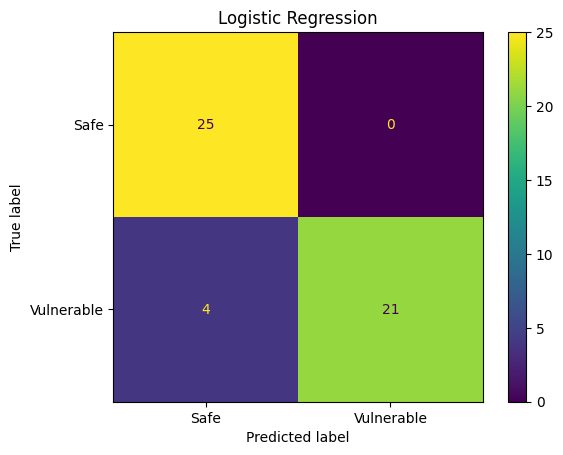

In [5]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=['Safe','Vulnerable']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Safe','Vulnerable']).plot()
plt.title('Logistic Regression')
plt.savefig('./data/cm_lr.png')
plt.show()

## 6. Random Forest

Same training data, different algorithm. RF can pick up interactions between tokens (e.g. `innerHTML` only matters when `location.search` shows up nearby). If LR keeps up with RF the signal is mostly additive.

              precision    recall  f1-score   support

        Safe       0.83      1.00      0.91        25
  Vulnerable       1.00      0.80      0.89        25

    accuracy                           0.90        50
   macro avg       0.92      0.90      0.90        50
weighted avg       0.92      0.90      0.90        50



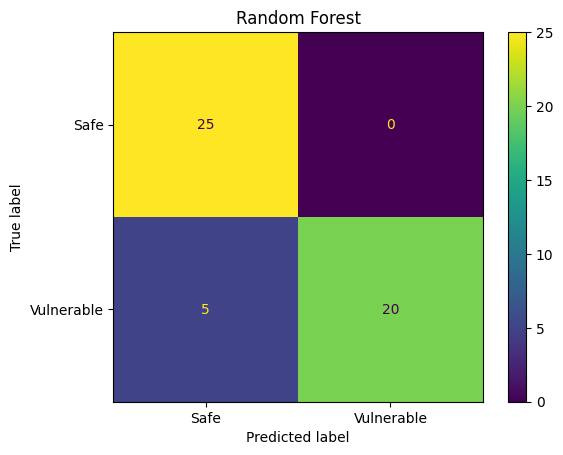

In [6]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=['Safe','Vulnerable']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Safe','Vulnerable']).plot()
plt.title('Random Forest')
plt.savefig('./data/cm_rf.png')
plt.show()

## 7. 5-Fold Cross-Validation

A single split can be lucky. 5-fold reports mean +/- std, which is a more honest read.


LR:
  precision: 0.847 (+/- 0.078)
  recall: 0.847 (+/- 0.068)
  f1: 0.843 (+/- 0.048)

RF:
  precision: 0.840 (+/- 0.046)
  recall: 0.855 (+/- 0.086)
  f1: 0.843 (+/- 0.035)


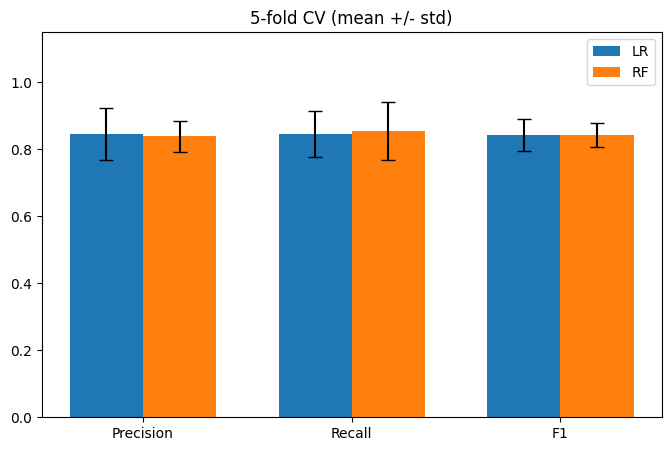

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1']

lr_cv = cross_validate(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
                       X, y, cv=cv, scoring=scoring)
rf_cv = cross_validate(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
                       X, y, cv=cv, scoring=scoring)

for name, res in [('LR', lr_cv), ('RF', rf_cv)]:
    print(f'\n{name}:')
    for m in scoring:
        v = res[f'test_{m}']
        print(f'  {m}: {v.mean():.3f} (+/- {v.std():.3f})')

# bar chart, error bars = std
x = np.arange(len(scoring))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [lr_cv[f'test_{m}'].mean() for m in scoring], w,
       yerr=[lr_cv[f'test_{m}'].std() for m in scoring], label='LR', capsize=5)
ax.bar(x + w/2, [rf_cv[f'test_{m}'].mean() for m in scoring], w,
       yerr=[rf_cv[f'test_{m}'].std() for m in scoring], label='RF', capsize=5)
ax.set_xticks(x); ax.set_xticklabels(['Precision','Recall','F1'])
ax.set_ylim(0, 1.15); ax.legend()
ax.set_title('5-fold CV (mean +/- std)')
plt.savefig('./data/cv_results.png')
plt.show()

## 8. Feature Importance

Each LR weight = how strongly a token pushes toward vulnerable (positive) or safe (negative). Just a sanity check that the model is paying attention to meaningful tokens like `innerHTML`.

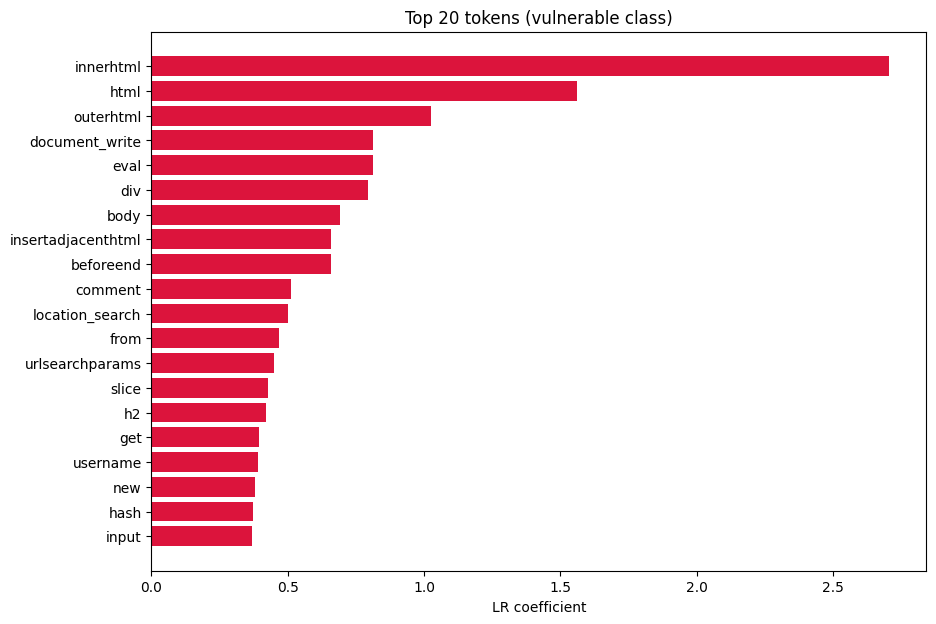

Top 10 vulnerable:
  innerhtml: 2.7065
  html: 1.5605
  outerhtml: 1.0270
  document_write: 0.8138
  eval: 0.8130
  div: 0.7949
  body: 0.6917
  insertadjacenthtml: 0.6571
  beforeend: 0.6571
  comment: 0.5129

Top 10 safe:
  innertext: -2.2381
  textcontent: -2.1998
  safe: -1.2335
  setattribute: -0.7864
  replace: -0.7192
  if: -0.6419
  getelementbyid: -0.6313
  com: -0.6274
  replacechildren: -0.6014
  https: -0.5638


In [8]:
feature_names = vectoriser.get_feature_names_out()
coefs = lr.coef_[0]

top_idx = np.argsort(coefs)[-20:][::-1]
top_tokens = [feature_names[i] for i in top_idx]
top_weights = [coefs[i] for i in top_idx]

plt.figure(figsize=(10, 7))
plt.barh(top_tokens[::-1], top_weights[::-1], color='crimson')
plt.xlabel('LR coefficient')
plt.title('Top 20 tokens (vulnerable class)')
plt.savefig('./data/feature_importance.png')
plt.show()

print('Top 10 vulnerable:')
for t, w in zip(top_tokens[:10], top_weights[:10]):
    print(f'  {t}: {w:.4f}')

print('\nTop 10 safe:')
for i in np.argsort(coefs)[:10]:
    print(f'  {feature_names[i]}: {coefs[i]:.4f}')

## 9. Rule-Based Baseline

Proximity rule: if a dangerous sink (`innerHTML`) shows up within ~120 chars of a known source (`location.search`) -> vulnerable. If a sanitiser (`DOMPurify`, `textContent`) appears anywhere -> safe. Comparator for RQ2 (does ML beat a rule?).

              precision    recall  f1-score   support

        Safe       0.74      1.00      0.85        25
  Vulnerable       1.00      0.64      0.78        25

    accuracy                           0.82        50
   macro avg       0.87      0.82      0.81        50
weighted avg       0.87      0.82      0.81        50



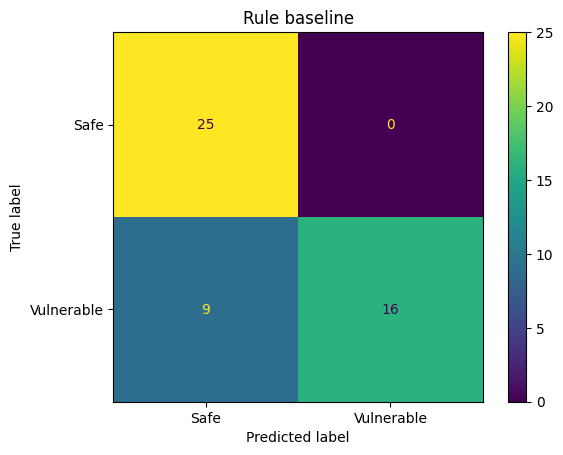

In [9]:
UNSAFE_SINKS = ['innerHTML', 'outerHTML', 'document.write', 'document.writeln', 'insertAdjacentHTML']
SOURCES      = ['location.search', 'location.hash', 'location.href',
                'document.referrer', '.value', 'props.']
SANITISERS   = ['DOMPurify', 'sanitize', 'createTextNode', 'textContent', 'innerText']

def rule_baseline(code):
    # if any sanitiser shows up at all, just call it safe (conservative shortcut)
    if any(s in code for s in SANITISERS):
        return 0
    for sink in UNSAFE_SINKS:
        i = code.find(sink)
        while i != -1:
            window = code[max(0, i-120):i+120]
            if any(src in window for src in SOURCES):
                return 1
            i = code.find(sink, i+1)
    return 0

baseline_preds = [rule_baseline(c) for c in df.iloc[test_idx]['code']]

print(classification_report(y_test, baseline_preds, target_names=['Safe','Vulnerable']))
ConfusionMatrixDisplay(confusion_matrix(y_test, baseline_preds),
                       display_labels=['Safe','Vulnerable']).plot()
plt.title('Rule baseline')
plt.savefig('./data/cm_rule.png')
plt.show()

## 10. Export Test Snippets for Semgrep

Semgrep runs on `.js` files on disk, not strings. Write the 50 test snippets out, filename embeds snippet_id so the findings map back.

In [10]:
import os
os.makedirs('./data/test_snippets', exist_ok=True)

for i, row in df.iloc[test_idx].reset_index(drop=True).iterrows():
    fname = f'test_{i:03d}_{row["snippet_id"]}.js'
    with open(f'./data/test_snippets/{fname}', 'w') as f:
        f.write(row['code'])

print(f'Wrote {len(test_idx)} snippets to ./data/test_snippets/')

Wrote 50 snippets to ./data/test_snippets/


## 11. Run Semgrep and Parse Output

Run Semgrep from the terminal:

```bash
semgrep --config xss.yml data/test_snippets/ --json --quiet > data/semgrep_output.json
```

Then this cell reads the JSON and turns it into predictions aligned with the test set order.

In [11]:
import json, os

# semgrep output came out utf-16 on my machine for some reason, handle both
with open('./data/semgrep_output.json', 'rb') as f:
    raw = f.read()
if raw[:2] in (b'\xff\xfe', b'\xfe\xff'):
    text = raw.decode('utf-16')
else:
    text = raw.decode('utf-8-sig')
sg = json.loads(text)

flagged = {os.path.basename(r['path'].replace('\\', '/')) for r in sg['results']}

y_pred_semgrep = []
for i, row in df.iloc[test_idx].reset_index(drop=True).iterrows():
    fname = f'test_{i:03d}_{row["snippet_id"]}.js'
    y_pred_semgrep.append(1 if fname in flagged else 0)

## 12. Side-by-Side Comparison

All four detectors on the held-out test set. F1 on the vulnerable class is the headline metric.

                     Precision  Recall     F1
Logistic Regression        1.0    0.84  0.913
Random Forest              1.0    0.80  0.889
Rule-Based Baseline        1.0    0.64  0.780
Semgrep                    0.0    0.00  0.000


/Users/RA/Desktop/Repository/XSS-Detector/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


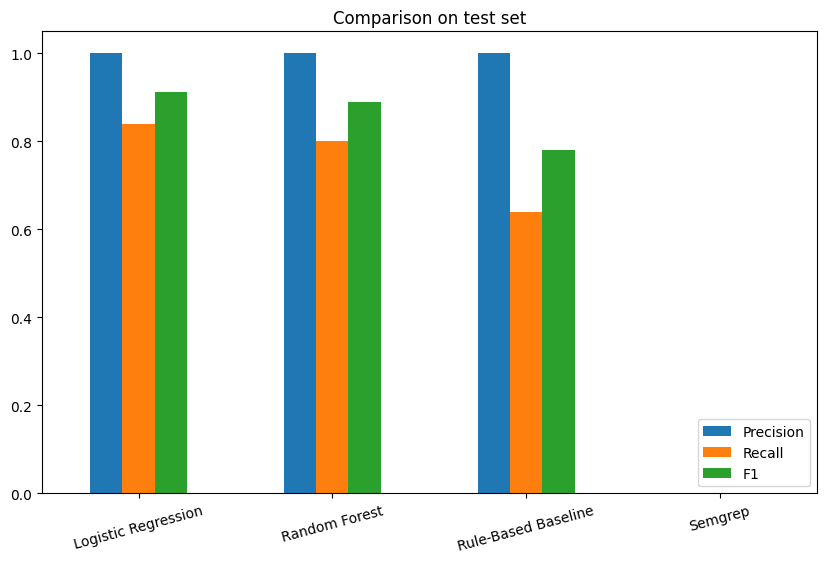

In [12]:
def get_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f, 3)}

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
    'Random Forest':       get_metrics(y_test, y_pred_rf),
    'Rule-Based Baseline': get_metrics(y_test, baseline_preds),
    'Semgrep':             get_metrics(y_test, y_pred_semgrep),
}).T
print(results)

results.plot(kind='bar', figsize=(10, 6), rot=15)
plt.title('Comparison on test set')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.savefig('./data/comparison.png')
plt.show()

## 13. Disagreement Analysis: ML vs Rule

Where ML and the rule disagree, who's right? Split into "ML correct, rule wrong" and the reverse, plus the snippet IDs for case-by-case discussion in the writeup.

In [13]:
# pick whichever ML model did better as the representative
best_preds = y_pred_lr if results.loc['Logistic Regression','F1'] >= results.loc['Random Forest','F1'] else y_pred_rf

test_df = df.iloc[test_idx].copy()
test_df['ground_truth']        = y_test
test_df['ml_prediction']       = best_preds
test_df['baseline_prediction'] = baseline_preds

disagreements = test_df[test_df['ml_prediction'] != test_df['baseline_prediction']]
ml_wins = disagreements[(disagreements['ml_prediction']       == disagreements['ground_truth']) &
                        (disagreements['baseline_prediction'] != disagreements['ground_truth'])]
bl_wins = disagreements[(disagreements['baseline_prediction'] == disagreements['ground_truth']) &
                        (disagreements['ml_prediction']       != disagreements['ground_truth'])]

print(f'Total disagreements: {len(disagreements)}')
print(f'ML correct, baseline wrong: {len(ml_wins)}')
print(f'Baseline correct, ML wrong: {len(bl_wins)}')

disagreements[['snippet_id','task_category','ml_prediction','baseline_prediction','ground_truth','sink']]

Total disagreements: 9
ML correct, baseline wrong: 7
Baseline correct, ML wrong: 2


,snippet_id,task_category,ml_prediction,baseline_prediction,ground_truth,sink
182,snippet_260,GitHub - real world,1,0,1,DANGEROUS:jQuery.html()
143,snippet_221,Form input live preview,1,0,1,DANGEROUS:Function() constructor
208,snippet_286,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
150,snippet_228,Username welcome message,1,0,1,DANGEROUS:setTimeout(string)
114,snippet_192,GitHub - real world,0,1,1,DANGEROUS:innerHTML
206,snippet_284,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
222,snippet_300,Dynamic script execution,1,0,1,DANGEROUS:setTimeout(string)
107,snippet_185,GitHub - real world,0,1,1,DANGEROUS:innerHTML
226,snippet_304,Server response rendering,1,0,1,DANGEROUS:innerHTML


## 14. Data Augmentation

Test whether the gap to Semgrep is data scale or representation. Expand the training set with label-preserving variants (rename generic vars, `var` -> `let`, swap quote style, prepend a benign comment). If F1 improves -> data scale. If it doesn't -> representational limit.

In [14]:
import random
random.seed(42); np.random.seed(42)

def augment(code):
    # label-preserving variants of one snippet
    out = [code]

    # rename generic identifiers
    renamed = code
    for pat, rep in [(r'\bvar\s+x\b',    'var userInput'),
                     (r'\bvar\s+y\b',    'var data'),
                     (r'\bvar\s+data\b', 'var payload'),
                     (r'\blet\s+x\b',    'let param'),
                     (r'\bvar\s+el\b',   'var element')]:
        renamed = re.sub(pat, rep, renamed)
    if renamed != code: out.append(renamed)

    # var -> let
    swapped = re.sub(r'\bvar\b', 'let', code)
    if swapped != code: out.append(swapped)

    # quote swap (only when one style is used, otherwise it breaks strings)
    if "'" in code and '"' not in code: out.append(code.replace("'", '"'))
    elif '"' in code and "'" not in code: out.append(code.replace('"', "'"))

    # benign comment prepend (ignored at runtime, adds new tokens to TF-IDF)
    out.append('// user input handler\n' + code)
    return out

aug_code, aug_labels = [], []
for c, l in zip(df.iloc[train_idx]['code'], y_train):
    for v in augment(c):
        aug_code.append(v); aug_labels.append(l)

# drop exact duplicates (some snippets dont have 'var' etc so variants collapse)
seen = set()
dedup_code, dedup_labels = [], []
for c, l in zip(aug_code, aug_labels):
    if c not in seen:
        seen.add(c); dedup_code.append(c); dedup_labels.append(l)

print(f'Original: {len(train_idx)} -> Augmented: {len(dedup_code)}  ({len(dedup_code)/len(train_idx):.2f}x)')

# refit vectoriser bc the vocab grows
vec_aug = TfidfVectorizer(min_df=2, max_df=0.95, max_features=500)
X_train_aug = vec_aug.fit_transform([tokenise(c) for c in dedup_code])
X_test_aug  = vec_aug.transform([tokenise(c) for c in df.iloc[test_idx]['code']])

lr_aug = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).fit(X_train_aug, dedup_labels)
rf_aug = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42).fit(X_train_aug, dedup_labels)
y_pred_lr_aug = lr_aug.predict(X_test_aug)
y_pred_rf_aug = rf_aug.predict(X_test_aug)

orig_lr = precision_recall_fscore_support(y_test, y_pred_lr,     average='binary')[2]
new_lr  = precision_recall_fscore_support(y_test, y_pred_lr_aug, average='binary')[2]
orig_rf = precision_recall_fscore_support(y_test, y_pred_rf,     average='binary')[2]
new_rf  = precision_recall_fscore_support(y_test, y_pred_rf_aug, average='binary')[2]
print(f'LR F1: {orig_lr:.3f} -> {new_lr:.3f}  ({new_lr-orig_lr:+.3f})')
print(f'RF F1: {orig_rf:.3f} -> {new_rf:.3f}  ({new_rf-orig_rf:+.3f})')

Original: 200 -> Augmented: 612  (3.06x)
LR F1: 0.913 -> 0.889  (-0.024)
RF F1: 0.889 -> 0.833  (-0.056)


## 15. Bootstrap 95% CIs

Test set is only 50 snippets so a single F1 estimate is fragile. Resample the test set with replacement 1000 times and take the 2.5/97.5 percentiles of the F1 distribution.

In [15]:
def bootstrap_f1(y_true, y_pred, n=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    f1s = []
    for _ in range(n):
        idx = rng.randint(0, len(y_true), size=len(y_true))
        if len(set(y_true[idx])) < 2:   # skip resamples with only one class
            continue
        _, _, f, _ = precision_recall_fscore_support(y_true[idx], y_pred[idx],
                                                     average='binary', zero_division=0)
        f1s.append(f)
    return np.percentile(f1s, [2.5, 97.5]), np.mean(f1s)

print('F1 95% CIs (1000 bootstrap resamples):')
for name, preds in [('LR', y_pred_lr), ('RF', y_pred_rf),
                    ('Rule', baseline_preds), ('Semgrep', y_pred_semgrep),
                    ('LR(aug)', y_pred_lr_aug), ('RF(aug)', y_pred_rf_aug)]:
    (lo, hi), mean = bootstrap_f1(y_test, preds)
    print(f'  {name:10}: [{lo:.3f}, {hi:.3f}]  mean {mean:.3f}')

F1 95% CIs (1000 bootstrap resamples):
  LR        : [0.811, 0.982]  mean 0.909
  RF        : [0.766, 0.974]  mean 0.885
  Rule      : [0.622, 0.895]  mean 0.771
  Semgrep   : [0.000, 0.000]  mean 0.000
  LR(aug)   : [0.765, 0.976]  mean 0.884
  RF(aug)   : [0.700, 0.936]  mean 0.828


## 16. McNemar's Test

Two detectors on the same test set -> paired predictions. McNemar asks whether their disagreements split evenly (chance) or lopsided (one detector is systematically better). Small p = real difference.

In [16]:
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'statsmodels'])
    from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, a, b, name_a, name_b):
    # exact binomial bc the off-diagonals (n10, n01) are small
    y_true = np.array(y_true)
    a_r = np.array(a) == y_true
    b_r = np.array(b) == y_true
    n11 = int(( a_r &  b_r).sum())
    n10 = int(( a_r & ~b_r).sum())
    n01 = int((~a_r &  b_r).sum())
    n00 = int((~a_r & ~b_r).sum())
    p = mcnemar([[n11, n10], [n01, n00]], exact=True).pvalue
    print(f'  {name_a:10} vs {name_b:10}: only {name_a}={n10}, only {name_b}={n01}, p={p:.4f}')

print('McNemar exact tests:')
mcnemar_test(y_test, y_pred_lr,      baseline_preds, 'LR',      'Rule')
mcnemar_test(y_test, y_pred_lr,      y_pred_semgrep, 'LR',      'Semgrep')
mcnemar_test(y_test, y_pred_semgrep, baseline_preds, 'Semgrep', 'Rule')
mcnemar_test(y_test, y_pred_lr_aug,  y_pred_lr,      'LR(aug)', 'LR(orig)')
mcnemar_test(y_test, y_pred_lr,      y_pred_rf,      'LR',      'RF')

McNemar exact tests:
  LR         vs Rule      : only LR=7, only Rule=2, p=0.1797
  LR         vs Semgrep   : only LR=21, only Semgrep=0, p=0.0000
  Semgrep    vs Rule      : only Semgrep=0, only Rule=16, p=0.0000
  LR(aug)    vs LR(orig)  : only LR(aug)=0, only LR(orig)=1, p=1.0000
  LR         vs RF        : only LR=2, only RF=1, p=1.0000


## 17. Subpopulation Analysis

One category ("GitHub - real world") was sourced differently from the other 17 prompt-generated ones. Compute metrics on each subset separately so the methodological compromise is visible.

In [17]:
test_df_sub = df.iloc[test_idx].reset_index(drop=True)
github_mask = (test_df_sub['task_category'] == 'GitHub - real world').values
prompt_mask = ~github_mask  # the other 17 categories

print(f'Prompt-generated: n={prompt_mask.sum()}, GitHub real-world: n={github_mask.sum()}')

def subset_metrics(name, mask, preds_list):
    print(f'\n{name} (n={mask.sum()}):')
    yt = y_test[mask]
    for pname, preds in preds_list:
        yp = np.array(preds)[mask]
        if sum(yt) == 0:
            print(f'  {pname:10}: no positives in subset')
            continue
        tp = int(((yp==1) & (yt==1)).sum())
        fn = int(((yp==0) & (yt==1)).sum())
        fp = int(((yp==1) & (yt==0)).sum())
        p, r, f, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        print(f'  {pname:10}: TP={tp}, FN={fn}, FP={fp}, P={p:.3f}, R={r:.3f}, F1={f:.3f}')

preds_list = [('LR', y_pred_lr), ('RF', y_pred_rf),
              ('Rule', baseline_preds), ('Semgrep', y_pred_semgrep)]

subset_metrics('Prompt-generated only', prompt_mask, preds_list)
subset_metrics('GitHub real-world only', github_mask, preds_list)

Prompt-generated: n=46, GitHub real-world: n=4

Prompt-generated only (n=46):
  LR        : TP=20, FN=2, FP=0, P=1.000, R=0.909, F1=0.952
  RF        : TP=18, FN=4, FP=0, P=1.000, R=0.818, F1=0.900
  Rule      : TP=14, FN=8, FP=0, P=1.000, R=0.636, F1=0.778
  Semgrep   : TP=0, FN=22, FP=0, P=0.000, R=0.000, F1=0.000

GitHub real-world only (n=4):
  LR        : TP=1, FN=2, FP=0, P=1.000, R=0.333, F1=0.500
  RF        : TP=2, FN=1, FP=0, P=1.000, R=0.667, F1=0.800
  Rule      : TP=2, FN=1, FP=0, P=1.000, R=0.667, F1=0.800
  Semgrep   : TP=0, FN=3, FP=0, P=0.000, R=0.000, F1=0.000


## 18. Combination Detector + FN Overlap

RQ3: does combining ML with Semgrep catch more? On this test set the answer is no - Semgrep's false negatives are a superset of LR's, so the union doesn't catch anything new. Both miss the same 4 snippets, which points to a shared blind spot for indirect-flow patterns.

In [18]:
# union rule: vulnerable if either LR or Semgrep flags it
y_pred_combo = [1 if (a or b) else 0 for a, b in zip(y_pred_lr, y_pred_semgrep)]
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_combo, average='binary')
print(f'Combination (LR OR Semgrep): P={p:.3f}  R={r:.3f}  F1={f:.3f}')

# which snippets did each miss?
test_snippets = df.iloc[test_idx].reset_index(drop=True)
lr_fn = {test_snippets.iloc[i]['snippet_id'] for i, p in enumerate(y_pred_lr)      if y_test[i]==1 and p==0}
sg_fn = {test_snippets.iloc[i]['snippet_id'] for i, p in enumerate(y_pred_semgrep) if y_test[i]==1 and p==0}

print(f'\nLR false negatives:      {sorted(lr_fn)}')
print(f'Semgrep false negatives: {sorted(sg_fn)}')
print(f'Missed by both:          {sorted(lr_fn & sg_fn)}')
print(f'Only LR misses:          {sorted(lr_fn - sg_fn)}')
print(f'Only Semgrep misses:     {sorted(sg_fn - lr_fn)}')

Combination (LR OR Semgrep): P=1.000  R=0.840  F1=0.913

LR false negatives:      ['snippet_185', 'snippet_192', 'snippet_269', 'snippet_306']
Semgrep false negatives: ['snippet_004', 'snippet_038', 'snippet_053', 'snippet_087', 'snippet_110', 'snippet_158', 'snippet_166', 'snippet_185', 'snippet_192', 'snippet_204', 'snippet_218', 'snippet_221', 'snippet_228', 'snippet_240', 'snippet_246', 'snippet_251', 'snippet_257', 'snippet_260', 'snippet_269', 'snippet_275', 'snippet_284', 'snippet_286', 'snippet_300', 'snippet_304', 'snippet_306']
Missed by both:          ['snippet_185', 'snippet_192', 'snippet_269', 'snippet_306']
Only LR misses:          []
Only Semgrep misses:     ['snippet_004', 'snippet_038', 'snippet_053', 'snippet_087', 'snippet_110', 'snippet_158', 'snippet_166', 'snippet_204', 'snippet_218', 'snippet_221', 'snippet_228', 'snippet_240', 'snippet_246', 'snippet_251', 'snippet_257', 'snippet_260', 'snippet_275', 'snippet_284', 'snippet_286', 'snippet_300', 'snippet_304']
